# PCA on Correlation Matrices (Train Fit, Test Evaluation)
Fit PCA on flattened train correlation matrices and reconstruct the test matrices using the learned components.
Compute reconstruction errors (MSE, MAE, Frobenius) on the test set, while explained variance is reported from the train fit.

In [10]:
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore', message='.*Clustering large matrix.*')

np.set_printoptions(suppress=True, precision=4)

## Step 1: Load Train/Val/Test Splits
Load correlation matrices from an existing dataset folder under `data/processed/dataset/`.
The folder must contain `train.pt`, `val.pt`, and `test.pt` with correlation matrices already split.

In [11]:
# Dataset path configuration
FILE_NAME = 'data_00_20'
WINDOW_SIZE = 724
STRIDE = 10
DATASET_DIR = Path('../data/processed') / FILE_NAME / 'dataset' / f'{FILE_NAME}_w{WINDOW_SIZE}_s{STRIDE}'

TRAIN_FILE = DATASET_DIR / 'train.pt'
VAL_FILE = DATASET_DIR / 'val.pt'
TEST_FILE = DATASET_DIR / 'test.pt'
ALL_FILE = DATASET_DIR / 'all.pt'

for split_path in (TRAIN_FILE, VAL_FILE, TEST_FILE, ALL_FILE):
    if not split_path.exists():
        raise FileNotFoundError(f'File not found: {split_path.resolve()}')

print(f'Dataset folder: {DATASET_DIR.name}')
print(f'Train: {TRAIN_FILE.name} | Val: {VAL_FILE.name} | Test: {TEST_FILE.name} | All: {ALL_FILE.name}')

Dataset folder: data_00_20_w724_s10
Train: train.pt | Val: val.pt | Test: test.pt | All: all.pt


In [12]:
def load_dataset_payload(pt_path: Path):
    payload = torch.load(pt_path, map_location='cpu')

    if isinstance(payload, dict):
        corr_tensor = payload.get('corr_tensor', None)
        # --- MODIFICA: Estrazione del tensore di Cholesky ---
        chol_tensor = payload.get('chol_tensor', None)
        meta = {k: v for k, v in payload.items() if k not in ('corr_tensor', 'chol_tensor')}
    elif isinstance(payload, torch.Tensor):
        corr_tensor = payload
        chol_tensor = None
        meta = {}
    else:
        raise TypeError(f'Unsupported .pt format: {type(payload)}')
    
    # --- MODIFICA: Controllo presenza del tensore di Cholesky ---
    if chol_tensor is None:
        raise KeyError('chol_tensor key not found in .pt file. Assicurati di aver generato il dataset con il nuovo script.')

    if corr_tensor.ndim != 3 or corr_tensor.shape[1] != corr_tensor.shape[2]:
        raise ValueError(f'Invalid shape for corr_tensor: {corr_tensor.shape}')
        
    if chol_tensor.ndim != 3 or chol_tensor.shape[1] != chol_tensor.shape[2]:
        raise ValueError(f'Invalid shape for chol_tensor: {chol_tensor.shape}')

    # Restituiamo entrambi i tensori
    return corr_tensor.float(), chol_tensor.float(), meta

# --- MODIFICA: Assegnazione multipla per accogliere chol_tensor ---
train_corr, train_chol, train_meta = load_dataset_payload(TRAIN_FILE)
val_corr, val_chol, val_meta = load_dataset_payload(VAL_FILE)
test_corr, test_chol, test_meta = load_dataset_payload(TEST_FILE)
all_corr, all_chol, all_meta = load_dataset_payload(ALL_FILE)

if train_chol.shape[1:] != test_chol.shape[1:]:
    raise ValueError(f'Train/test asset dims mismatch: {train_chol.shape} vs {test_chol.shape}')
if val_chol.shape[1:] != train_chol.shape[1:]:
    raise ValueError(f'Val/train asset dims mismatch: {val_chol.shape} vs {train_chol.shape}')

print(f"{'='*50}")
print("SHAPES CARICATE:")
print(f"{'='*50}")
print(f"train_corr shape: {str(tuple(train_corr.shape)):<15} | train_chol shape: {tuple(train_chol.shape)}")
print(f"val_corr shape:   {str(tuple(val_corr.shape)):<15} | val_chol shape:   {tuple(val_chol.shape)}")
print(f"test_corr shape:  {str(tuple(test_corr.shape)):<15} | test_chol shape:  {tuple(test_chol.shape)}")
print(f"all_corr shape:   {str(tuple(all_corr.shape)):<15} | all_chol shape:   {tuple(all_chol.shape)}")

SHAPES CARICATE:
train_corr shape: (288, 362, 362) | train_chol shape: (288, 362, 362)
val_corr shape:   (82, 362, 362)  | val_chol shape:   (82, 362, 362)
test_corr shape:  (42, 362, 362)  | test_chol shape:  (42, 362, 362)
all_corr shape:   (412, 362, 362) | all_chol shape:   (412, 362, 362)


## Step 2: Prepare Train/Val/Test Matrices
Each correlation matrix is loaded as N x N.
If PCA_INPUT='cholesky_lower', PCA uses the flattened lower-triangular Cholesky factors (including diagonal).
If PCA_INPUT='corr', PCA uses the flattened lower-triangular correlations (excluding diagonal).
The validation split is loaded for completeness but not used later.

In [13]:
# --- 1. Utilizziamo i tensori di Cholesky ---
train_np = train_chol.numpy()
val_np = val_chol.numpy()
test_np = test_chol.numpy()
all_np = all_chol.numpy()

n_train, n_assets, _ = train_np.shape
n_val = val_np.shape[0]
n_test = test_np.shape[0]
n_all = all_np.shape[0]

print(f'Train matrices: {n_train}')
print(f'Val matrices:   {n_val}')
print(f'Test matrices:  {n_test}')
print(f'All matrices:   {n_all}')
print(f'Assets per matrix (N): {n_assets}')
print(f'Each input matrix shape: ({n_assets}, {n_assets})')

# --- 2. MODIFICA: Feature dimension (k=0 include la diagonale) ---
# Formula: N * (N + 1) / 2
feature_dim = n_assets * (n_assets + 1) // 2

print(f'Flattened feature dimension (inclusa diagonale): {feature_dim}')

Train matrices: 288
Val matrices:   82
Test matrices:  42
All matrices:   412
Assets per matrix (N): 362
Each input matrix shape: (362, 362)
Flattened feature dimension (inclusa diagonale): 65703


## Step 3: Fit PCA on Train, Reconstruct Test
For every matrix:
- If PCA_INPUT='cholesky_lower', flatten the lower-triangular Cholesky factor (including diagonal)
- If PCA_INPUT='corr', flatten the lower-triangular correlations (excluding diagonal)
- Fit PCA on the train split only
- Apply PCA to the test split and inverse transform to reconstruct
If using Cholesky, reconstructed correlation matrices are obtained via $L L^T$ and re-normalized to unit diagonal;
if using correlations, the lower triangle is mirrored and the diagonal is set to 1.
Errors are computed on the test split; explained variance is from the train fit.

In [14]:
def apply_pca(
    train_chol,
    eval_chol,
    n_components,
):

    if train_chol.ndim != 3 or train_chol.shape[1] != train_chol.shape[2]:
        raise ValueError(
            f'Expected train shape (n_samples, N, N), got {train_chol.shape}'
        )

    if eval_chol.ndim != 3 or eval_chol.shape[1] != eval_chol.shape[2]:
        raise ValueError(
            f'Expected eval shape (n_samples, N, N), got {eval_chol.shape}'
        )

    n_train, n_assets, _ = train_chol.shape
    n_eval, n_assets_eval, _ = eval_chol.shape

    if n_assets_eval != n_assets:
        raise ValueError(
            f'Train/eval asset dims mismatch: '
            f'{train_chol.shape} vs {eval_chol.shape}'
        )

    # Estrazione triangolo inferiore inclusa la diagonale
    tril_idx = np.tril_indices(n_assets, k=0)

    train_flat = train_chol[:, tril_idx[0], tril_idx[1]]
    eval_flat = eval_chol[:, tril_idx[0], tril_idx[1]]

    n_features = train_flat.shape[1]

    if not (1 <= n_components <= min(n_train, n_features)):
        raise ValueError(
            f'n_components must be in [1, {min(n_train, n_features)}]'
        )

    # PCA
    pca = PCA(n_components=n_components)
    pca.fit(train_flat)

    eval_proj = pca.transform(eval_flat)
    eval_recon = pca.inverse_transform(eval_proj).astype(np.float32)

    # Ricostruzione del fattore di Cholesky
    recon_L = np.zeros(
        (n_eval, n_assets, n_assets),
        dtype=np.float32
    )

    recon_L[:, tril_idx[0], tril_idx[1]] = eval_recon

    # PSD garantita
    recon_PSD = recon_L @ np.transpose(recon_L, axes=(0, 2, 1))

    # Conversione PSD -> Correlation
    diag = np.diagonal(recon_PSD, axis1=1, axis2=2)

    d_inv_sqrt = 1.0 / np.sqrt(
        np.maximum(diag, 1e-12)
    )

    recon_corr = (
        recon_PSD
        * d_inv_sqrt[:, :, np.newaxis]
        * d_inv_sqrt[:, np.newaxis, :]
    )

    # Pulizia numerica
    recon_corr = np.clip(recon_corr, -1.0, 1.0)

    diag_idx = np.arange(n_assets)
    recon_corr[:, diag_idx, diag_idx] = 1.0

    return {
        'recon_corr': recon_corr,
        'recon_chol': recon_L,
        'explained_variance': pca.explained_variance_ratio_,
        'pca': pca,
    }

In [22]:
# --- 1. Preparazione degli input (Cholesky Factors) ---
# Dobbiamo usare i tensori di Cholesky, non quelli di correlazione
train_chol_np = train_chol.numpy().astype(np.float32)
val_chol_np = val_chol.numpy().astype(np.float32)
test_chol_np = test_chol.numpy().astype(np.float32)
all_chol_np = all_chol.numpy().astype(np.float32)

N_COMPONENTS = 3

# --- 2. Esecuzione PCA su Cholesky ---
# Nota: apply_pca ora gestisce internamente k=0 e la ricostruzione LL^T
pca_out = apply_pca(
    train_chol_np,  # Input modificato
    test_chol_np,   # Input modificato
    n_components=N_COMPONENTS,
)

recon_corr = pca_out['recon_corr']
mean_explained_ratio = pca_out['explained_variance']
pca = pca_out['pca']

var_percent = mean_explained_ratio.sum() * 100

print('--- PCA Reconstruction (Fit su Cholesky, Test su Cholesky) ---')
print(f'Train Cholesky shape:       {train_chol_np.shape}')
print(f'Test Cholesky shape:        {test_chol_np.shape}')
print(f'Reconstructed corr shape:   {recon_corr.shape}')
print(f'Components kept (K):        {N_COMPONENTS}')
print(f'Cumulative explained variance: {var_percent:.2f}%\n')

for idx, var in enumerate(mean_explained_ratio):
    print(f'Variance PC{idx+1}: {(var * 100):.2f}%')

--- PCA Reconstruction (Fit su Cholesky, Test su Cholesky) ---
Train Cholesky shape:       (288, 362, 362)
Test Cholesky shape:        (42, 362, 362)
Reconstructed corr shape:   (42, 362, 362)
Components kept (K):        3
Cumulative explained variance: 56.63%

Variance PC1: 21.97%
Variance PC2: 18.70%
Variance PC3: 15.97%


## Step 4: Matrix-Level Reconstruction Visualization
Visualize one reconstructed matrix with:
- Hierarchical clustering heatmaps (original, reconstructed, error)
- Standard heatmaps without clustering (original order preserved)

Original Matrix:
[[1.     0.1809 0.146  0.0234 0.1973]
 [0.1809 1.     0.2591 0.1597 0.3356]
 [0.146  0.2591 1.     0.0816 0.1628]
 [0.0234 0.1597 0.0816 1.     0.1173]
 [0.1973 0.3356 0.1628 0.1173 1.    ]]
Reconstructed Matrix:
[[1.     0.2071 0.1642 0.1075 0.265 ]
 [0.2071 1.     0.2071 0.1916 0.3222]
 [0.1642 0.2071 1.     0.1381 0.2429]
 [0.1075 0.1916 0.1381 1.     0.1826]
 [0.265  0.3222 0.2429 0.1826 1.    ]]
Error Matrix:
[[ 0.      0.0263  0.0182  0.0841  0.0677]
 [ 0.0263  0.     -0.0519  0.0318 -0.0134]
 [ 0.0182 -0.0519  0.      0.0566  0.0801]
 [ 0.0841  0.0318  0.0566  0.      0.0653]
 [ 0.0677 -0.0134  0.0801  0.0653  0.    ]]
Sample index: 0
MSE: 0.003537 | MAE: 0.045805 | Frobenius: 21.528826
Error range - Min: -0.290919 | Max: 0.447116


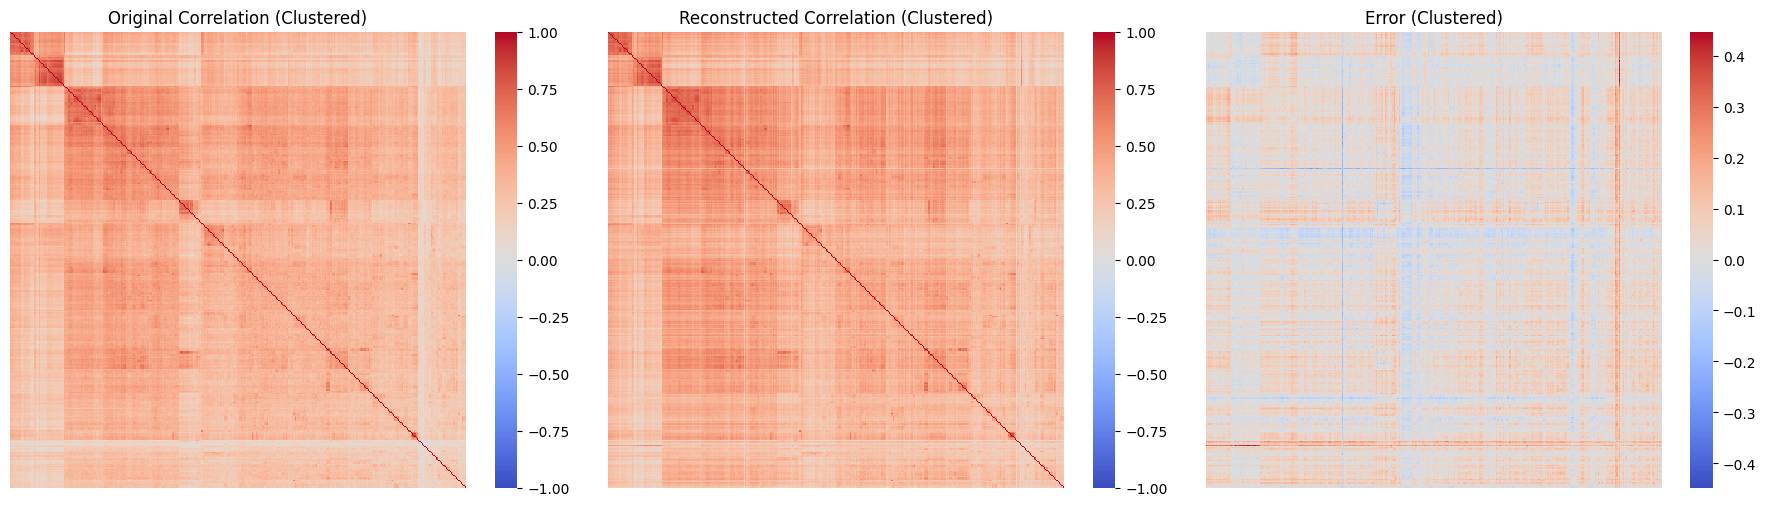

In [23]:
SAMPLE_IDX = 0

if not (0 <= SAMPLE_IDX < test_corr.shape[0]):
    raise ValueError(f'SAMPLE_IDX must be in [0, {test_corr.shape[0] - 1}]')

# CORRECT SPACE: correlation matrices
orig_mat = test_corr.numpy()[SAMPLE_IDX]
recon_mat = recon_corr[SAMPLE_IDX]

err_mat = recon_mat - orig_mat

print(f"Original Matrix:\n{orig_mat[:5, :5]}")
print(f"Reconstructed Matrix:\n{recon_mat[:5, :5]}")
print(f"Error Matrix:\n{err_mat[:5, :5]}")

mse_sample = float(np.mean(err_mat ** 2))
mae_sample = float(np.mean(np.abs(err_mat)))
fro_sample = float(np.linalg.norm(err_mat, ord='fro'))

print(f'Sample index: {SAMPLE_IDX}')
print(f'MSE: {mse_sample:.6f} | MAE: {mae_sample:.6f} | Frobenius: {fro_sample:.6f}')
print(f'Error range - Min: {err_mat.min():.6f} | Max: {err_mat.max():.6f}')

shared_cmap = 'coolwarm'

err_abs_max = float(np.max(np.abs(err_mat)))
if err_abs_max == 0:
    err_abs_max = 1e-6

# Clustering
cluster_ref = sns.clustermap(
    orig_mat,
    vmin=-1,
    vmax=1,
    cmap=shared_cmap,
    linewidths=0,
    figsize=(8, 8),
)
row_order = cluster_ref.dendrogram_row.reordered_ind
col_order = cluster_ref.dendrogram_col.reordered_ind
plt.close(cluster_ref.fig)

orig_mat_clustered = orig_mat[np.ix_(row_order, col_order)]
recon_mat_clustered = recon_mat[np.ix_(row_order, col_order)]
err_mat_clustered = err_mat[np.ix_(row_order, col_order)]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(orig_mat_clustered, ax=axes[0], vmin=-1, vmax=1, cmap=shared_cmap, square=True)
axes[0].set_title('Original Correlation (Clustered)')

sns.heatmap(recon_mat_clustered, ax=axes[1], vmin=-1, vmax=1, cmap=shared_cmap, square=True)
axes[1].set_title('Reconstructed Correlation (Clustered)')

sns.heatmap(err_mat_clustered, ax=axes[2], vmin=-err_abs_max, vmax=err_abs_max,
            cmap=shared_cmap, center=0, square=True)
axes[2].set_title('Error (Clustered)')

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

## Step 5: Calculate Reconstruction Errors (Train/Test)
Measure reconstruction quality on the train and test splits using three metrics:
- **MSE**: Mean Squared Error
- **MAE**: Mean Absolute Error  
- **Frobenius**: Frobenius norm of the difference

In [24]:

def reconstruction_errors(original: np.ndarray, reconstructed: np.ndarray) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Calcola gli errori di ricostruzione (MSE, MAE, Frobenius) per un batch di matrici.
    
    Args:
        original (np.ndarray): Tensore delle matrici originali di shape (n_samples, n_assets, n_assets).
        reconstructed (np.ndarray): Tensore delle matrici ricostruite di shape (n_samples, n_assets, n_assets).
        
    Returns:
        tuple[pd.DataFrame, pd.DataFrame]: 
            - summary: DataFrame con gli errori per ogni singola matrice.
            - stats: DataFrame con le statistiche aggregate (mean, std, min, median, max).
    """
    if original.shape != reconstructed.shape:
        raise ValueError(
            f"Input shapes mismatch: original {original.shape} vs reconstructed {reconstructed.shape}"
        )

    # Calcolo della matrice delle differenze
    diff = reconstructed - original

    # Metriche calcolate per ogni singola matrice lungo gli assi (1, 2)
    mse_per_matrix = np.mean(diff ** 2, axis=(1, 2))
    mae_per_matrix = np.mean(np.abs(diff), axis=(1, 2))
    fro_per_matrix = np.linalg.norm(diff, ord='fro', axis=(1, 2))

    # Costruzione del DataFrame di dettaglio
    summary = pd.DataFrame({
        'MSE': mse_per_matrix,
        'MAE': mae_per_matrix,
        'Frobenius': fro_per_matrix,
    })

    # Aggregazione delle statistiche generali
    stats = summary.agg(['mean', 'std', 'min', 'median', 'max']).T

    return summary, stats
# --- FUNZIONE DI RICOSTRUZIONE ---
def rebuild_from_cholesky(recon_flat: np.ndarray, n_assets: int):
    """
    Trasforma un array piatto di fattori di Cholesky in matrici di correlazione PSD.
    """
    n_samples = recon_flat.shape[0]
    tril_idx = np.tril_indices(n_assets, k=0)
    
    recon_L = np.zeros((n_samples, n_assets, n_assets), dtype=np.float32)
    recon_L[:, tril_idx[0], tril_idx[1]] = recon_flat
    
    recon_PSD = recon_L @ np.transpose(recon_L, axes=(0, 2, 1))
    
    diag = np.diagonal(recon_PSD, axis1=1, axis2=2)
    d_inv_sqrt = 1.0 / np.sqrt(np.maximum(diag, 1e-12))
    
    recon_corr = recon_PSD * d_inv_sqrt[:, :, np.newaxis] * d_inv_sqrt[:, np.newaxis, :]
    recon_corr = np.clip(recon_corr, -1.0, 1.0)
    
    diag_idx = np.arange(n_assets)
    recon_corr[:, diag_idx, diag_idx] = 1.0
    
    return recon_corr

# =========================================================
# ESECUZIONE SUI 4 DATASET (Molto più snello!)
# =========================================================
tril_idx = np.tril_indices(n_assets, k=0)

# 1. TRAIN SET
train_flat = train_chol[:, tril_idx[0], tril_idx[1]]
recon_train_flat = pca.inverse_transform(pca.transform(train_flat))
recon_train_corr = rebuild_from_cholesky(recon_train_flat, n_assets)

errors_df_train, errors_stats_train = reconstruction_errors(train_corr.numpy(), recon_train_corr)
print('--- Matrix Reconstruction Errors (Train Set) ---')
display(errors_stats_train)

# 2. VALIDATION SET
val_flat = val_chol[:, tril_idx[0], tril_idx[1]]
recon_val_flat = pca.inverse_transform(pca.transform(val_flat))
recon_val_corr = rebuild_from_cholesky(recon_val_flat, n_assets)

errors_df_val, errors_stats_val = reconstruction_errors(val_corr.numpy(), recon_val_corr)
print('\n--- Matrix Reconstruction Errors (Validation Set) ---')
display(errors_stats_val)

# 3. TEST SET
test_flat = test_chol[:, tril_idx[0], tril_idx[1]]
recon_test_flat = pca.inverse_transform(pca.transform(test_flat))
recon_test_corr = rebuild_from_cholesky(recon_test_flat, n_assets)

errors_df_test, errors_stats_test = reconstruction_errors(test_corr.numpy(), recon_test_corr)
print('\n--- Matrix Reconstruction Errors (Test Set) ---')
display(errors_stats_test)

# 4. ALL SET
all_flat = all_chol[:, tril_idx[0], tril_idx[1]]
recon_all_flat = pca.inverse_transform(pca.transform(all_flat))
recon_all_corr = rebuild_from_cholesky(recon_all_flat, n_assets)

errors_df_all, errors_stats_all = reconstruction_errors(all_corr.numpy(), recon_all_corr)
print('\n--- Matrix Reconstruction Errors (All Set) ---')
display(errors_stats_all)

--- Matrix Reconstruction Errors (Train Set) ---


,mean,std,min,median,max
MSE,0.003379,0.002143,0.000598,0.002784,0.009170
MAE,0.045245,0.014914,0.019016,0.042744,0.081697
Frobenius,20.073051,6.328595,8.853601,19.099726,34.664982



--- Matrix Reconstruction Errors (Validation Set) ---


,mean,std,min,median,max
MSE,0.003457,0.002022,0.001018,0.002816,0.008445
MAE,0.045793,0.014011,0.024861,0.041904,0.078636
Frobenius,20.472406,5.857286,11.549537,19.210979,33.266125



--- Matrix Reconstruction Errors (Test Set) ---


,mean,std,min,median,max
MSE,0.003556,0.001860,0.000814,0.003146,0.008238
MAE,0.046392,0.012477,0.022636,0.046046,0.075395
Frobenius,20.880001,5.540364,10.326696,20.305584,32.856991



--- Matrix Reconstruction Errors (All Set) ---


,mean,std,min,median,max
MSE,0.003413,0.002088,0.000598,0.002872,0.009170
MAE,0.045471,0.014481,0.019016,0.043545,0.081697
Frobenius,20.234797,6.153307,8.853601,19.399952,34.664982


## Step 7: Error Analysis Across Components
Sweep over different numbers of K components, fitting PCA on the train split and evaluating reconstruction errors on the train and test sets.

In [29]:
import json

candidate_components = [3, 10, 20, 25, 100, 288]
n_train = train_chol_np.shape[0]  # Usa la dimensione del dataset
feature_dim = (n_assets * (n_assets + 1)) // 2 # k=0 include diagonale

max_components = min(n_train, feature_dim)
candidate_components = [c for c in candidate_components if c <= max_components]
print(f'Evaluating reconstruction errors for components: {candidate_components}')


def rebuild_matrices(recon_flat: np.ndarray, n_assets: int):
    """
    Ricostruisce correttamente la pipeline:
    flat Cholesky → L → PSD → Correlation
    """
    n_samples = recon_flat.shape[0]
    tril_idx = np.tril_indices(n_assets, k=0)

    # 1. Ricostruzione L
    recon_L = np.zeros((n_samples, n_assets, n_assets), dtype=np.float32)
    recon_L[:, tril_idx[0], tril_idx[1]] = recon_flat

    # 2. PSD (L @ L.T)
    recon_PSD = recon_L @ recon_L.transpose(0, 2, 1)

    # 3. Normalizzazione a correlazione
    diag = np.diagonal(recon_PSD, axis1=1, axis2=2)
    d_inv_sqrt = 1.0 / np.sqrt(np.maximum(diag, 1e-12))

    recon_corr = (
        recon_PSD
        * d_inv_sqrt[:, :, None]
        * d_inv_sqrt[:, None, :]
    )

    # 4. stabilizzazione numerica
    recon_corr = np.clip(recon_corr, -1.0, 1.0)
    diag_idx = np.arange(n_assets)
    recon_corr[:, diag_idx, diag_idx] = 1.0

    return recon_corr

# 1. Carica i payload separati per ogni split
base_payloads = {
    'train': torch.load(TRAIN_FILE, map_location='cpu'),
    'val': torch.load(VAL_FILE, map_location='cpu'),
    'test': torch.load(TEST_FILE, map_location='cpu'),
    'all': torch.load(ALL_FILE, map_location='cpu'),
}

# Funzione helper per uniformare i payload
def get_template(payload):
    return payload if isinstance(payload, dict) else {'corr_tensor': payload}

payload_templates = {k: get_template(v) for k, v in base_payloads.items()}

def extract_tickers(payloads: dict):
    for payload in payloads.values():
        if not isinstance(payload, dict):
            continue
        if 'tickers' in payload:
            return payload.get('tickers')
        meta = payload.get('meta') or payload.get('metadata')
        if isinstance(meta, dict) and 'tickers' in meta:
            return meta.get('tickers')
    return None

tickers = extract_tickers(payload_templates)
train_corr_np = train_corr.numpy().astype(np.float32)
val_corr_np = val_corr.numpy().astype(np.float32)
test_corr_np = test_corr.numpy().astype(np.float32)
all_corr_np = all_corr.numpy().astype(np.float32)

# --- MODIFICA CRITICA: Manteniamo i due domini separati ---
splits_chol = {
    'train': train_chol_np,
    'val': val_chol_np,
    'test': test_chol_np,
    'all': all_chol_np,
}

splits_corr = {
    'train': train_corr_np,
    'val': val_corr_np,
    'test': test_corr_np,
    'all': all_corr_np,
}

tril_idx = np.tril_indices(n_assets, k=0)

rows = []
sweep_payload = []
stat_cols = ["mean", "std", "min", "median", "max"]

for n_comp in candidate_components:
    # Modificato il path per indicare che stiamo usando PCA su Cholesky
    recon_dir = Path(
        f'../models/{FILE_NAME}_w{WINDOW_SIZE}_s{STRIDE}/PCA_cholesky/PCA_{n_comp}dim/analysis_outputs'
    )
    recon_dir.mkdir(parents=True, exist_ok=True)

    # Fit PCA solo sul train (su spazio CHOLESKY)
    train_flat = splits_chol['train'][:, tril_idx[0], tril_idx[1]]
    pca = PCA(n_components=n_comp)
    pca.fit(train_flat)

    explained_ratio = pca.explained_variance_ratio_
    cum_explained_ratio = float(explained_ratio.sum())
    cum_explained_ratio = min(cum_explained_ratio, 1.0)

    split_stats = {}

    for set_name in splits_chol.keys():
        # Trasforma e ricostruisce usando i dati CHOLESKY
        split_chol_flat = splits_chol[set_name][:, tril_idx[0], tril_idx[1]]
        split_recon_flat = pca.inverse_transform(pca.transform(split_chol_flat))
        split_recon_corr = rebuild_matrices(split_recon_flat, n_assets)

        # Calcola errore confrontando Correlazione Ricostruita con Correlazione Originale
        _, split_matrix_stats = reconstruction_errors(splits_corr[set_name], split_recon_corr)
        split_stats[set_name] = split_matrix_stats

        # --- SALVATAGGIO TENSORI ---
        extended_payload = dict(payload_templates[set_name])
        # Salviamo la matrice di correlazione ricostruita
        extended_payload['corr_tensor_reconstructed'] = torch.from_numpy(split_recon_corr).float()
        
        # Opzionale ma consigliato: salviamo anche i fattori di Cholesky ricostruiti nel caso servano
        split_recon_L = np.zeros((split_recon_flat.shape[0], n_assets, n_assets), dtype=np.float32)
        split_recon_L[:, tril_idx[0], tril_idx[1]] = split_recon_flat
        extended_payload['chol_tensor_reconstructed'] = torch.from_numpy(split_recon_L).float()

        if tickers is not None:
            extended_payload['tickers'] = tickers

        output_path = recon_dir / f'{set_name}_reconstructed_PCA_{n_comp}dim.pt'
        torch.save(extended_payload, output_path)
        print(f'Saved {set_name} reconstructed matrices for K={n_comp}: {output_path.resolve()}')

    # --- EXTRACTING STATS ---
    def extract_stats(stats_df):
        stats_dict = {}
        for metric in ["MSE", "MAE", "Frobenius"]:
            if metric in stats_df.index:
                stats_dict[metric] = {k: float(stats_df.loc[metric, stat_cols][k]) for k in stat_cols}
        return stats_dict

    train_err_stats = extract_stats(split_stats['train'])
    val_err_stats = extract_stats(split_stats['val'])
    test_err_stats = extract_stats(split_stats['test'])
    all_err_stats = extract_stats(split_stats['all'])

    # --- APPEND TO DATAFRAME ROWS ---
    rows.append({
        'n_components': n_comp,
        'mean_explained_variance': cum_explained_ratio,
        'Train_matrix_MSE_mean': float(train_err_stats["MSE"]["mean"]),
        'Train_matrix_MAE_mean': float(train_err_stats["MAE"]["mean"]),
        'Train_matrix_Frobenius_mean': float(train_err_stats["Frobenius"]["mean"]),
        'Val_matrix_MSE_mean': float(val_err_stats["MSE"]["mean"]),
        'Val_matrix_MAE_mean': float(val_err_stats["MAE"]["mean"]),
        'Val_matrix_Frobenius_mean': float(val_err_stats["Frobenius"]["mean"]),
        'Test_matrix_MSE_mean': float(test_err_stats["MSE"]["mean"]),
        'Test_matrix_MAE_mean': float(test_err_stats["MAE"]["mean"]),
        'Test_matrix_Frobenius_mean': float(test_err_stats["Frobenius"]["mean"]),
        'All_matrix_MSE_mean': float(all_err_stats["MSE"]["mean"]),
        'All_matrix_MAE_mean': float(all_err_stats["MAE"]["mean"]),
        'All_matrix_Frobenius_mean': float(all_err_stats["Frobenius"]["mean"]),
    })

    # --- APPEND TO JSON PAYLOAD ---
    sweep_payload.append({
        'n_components': n_comp,
        'mean_explained_variance': cum_explained_ratio,
        'reconstruction_errors_on_matrix_train': train_err_stats,
        'reconstruction_errors_on_matrix_val': val_err_stats,
        'reconstruction_errors_on_matrix_test': test_err_stats,
        'reconstruction_errors_on_matrix_all': all_err_stats,
    })

sweep_df = pd.DataFrame(rows)

# Print Summary Tables
train_cols = ['n_components', 'mean_explained_variance', 'Train_matrix_MSE_mean', 'Train_matrix_MAE_mean', 'Train_matrix_Frobenius_mean']
val_cols = ['n_components', 'mean_explained_variance', 'Val_matrix_MSE_mean', 'Val_matrix_MAE_mean', 'Val_matrix_Frobenius_mean']
test_cols = ['n_components', 'mean_explained_variance', 'Test_matrix_MSE_mean', 'Test_matrix_MAE_mean', 'Test_matrix_Frobenius_mean']
all_cols = ['n_components', 'mean_explained_variance', 'All_matrix_MSE_mean', 'All_matrix_MAE_mean', 'All_matrix_Frobenius_mean']

print('\n--- Train summary (Matrix) ---')
display(sweep_df[train_cols])

print('\n--- Validation summary (Matrix) ---')
display(sweep_df[val_cols])

print('\n--- Test summary (Matrix) ---')
display(sweep_df[test_cols])

print('\n--- All summary (Matrix) ---')
display(sweep_df[all_cols])

# Save JSON
sweep_path = Path(f'../models/{FILE_NAME}_w{WINDOW_SIZE}_s{STRIDE}/PCA_cholesky/reconstruction_errors.json')
sweep_path.parent.mkdir(parents=True, exist_ok=True)
with open(sweep_path, 'w') as f:
    json.dump(sweep_payload, f, indent=2)
print(f'\nSaved sweep_payload JSON to: {sweep_path.resolve()}')

Evaluating reconstruction errors for components: [3, 10, 20, 25, 100, 288]
Saved train reconstructed matrices for K=3: C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\models\data_00_20_w724_s10\PCA_cholesky\PCA_3dim\analysis_outputs\train_reconstructed_PCA_3dim.pt
Saved val reconstructed matrices for K=3: C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\models\data_00_20_w724_s10\PCA_cholesky\PCA_3dim\analysis_outputs\val_reconstructed_PCA_3dim.pt
Saved test reconstructed matrices for K=3: C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\models\data_00_20_w724_s10\PCA_cholesky\PCA_3dim\analysis_outputs\test_reconstructed_PCA_3dim.pt
Saved all reconstructed matrices for K=3: C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\models\data_00_20_w724_s10\PCA_cholesky\PCA_3dim\analysis_outputs\all_reconstructed_PCA_3dim.pt
Saved train reconstructed matrices for K=10: C:\Users\dylan\Desktop\TESI\Synthe

,n_components,mean_explained_variance,Train_matrix_MSE_mean,Train_matrix_MAE_mean,Train_matrix_Frobenius_mean
0,3,0.566331,3.379320e-03,4.524459e-02,20.073055
1,10,0.879800,4.864585e-04,1.623558e-02,7.689344
2,20,0.939728,2.136334e-04,1.040371e-02,5.026091
3,25,0.952423,1.476167e-04,8.571102e-03,4.216735
4,100,0.991129,1.972191e-05,3.004952e-03,1.555969
5,288,1.000000,1.416750e-13,3.224202e-07,0.000131



--- Validation summary (Matrix) ---


,n_components,mean_explained_variance,Val_matrix_MSE_mean,Val_matrix_MAE_mean,Val_matrix_Frobenius_mean
0,3,0.566331,0.003457,0.045793,20.472408
1,10,0.879800,0.000529,0.016712,7.938388
2,20,0.939728,0.000266,0.011493,5.535109
3,25,0.952423,0.000205,0.010025,4.889025
4,100,0.991129,0.000069,0.005269,2.689137
5,288,1.000000,0.000055,0.004458,2.303066



--- Test summary (Matrix) ---


,n_components,mean_explained_variance,Test_matrix_MSE_mean,Test_matrix_MAE_mean,Test_matrix_Frobenius_mean
0,3,0.566331,0.003556,0.046392,20.880001
1,10,0.879800,0.000555,0.017489,8.172482
2,20,0.939728,0.000273,0.011800,5.631571
3,25,0.952423,0.000203,0.010010,4.889961
4,100,0.991129,0.000074,0.005505,2.854042
5,288,1.000000,0.000057,0.004642,2.432773



--- All summary (Matrix) ---


,n_components,mean_explained_variance,All_matrix_MSE_mean,All_matrix_MAE_mean,All_matrix_Frobenius_mean
0,3,0.566331,0.003413,0.045471,20.234798
1,10,0.879800,0.000502,0.016458,7.788163
2,20,0.939728,0.000230,0.010763,5.189124
3,25,0.952423,0.000165,0.009007,4.419170
4,100,0.991129,0.000035,0.003710,1.913831
5,288,1.000000,0.000017,0.001361,0.706470



Saved sweep_payload JSON to: C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\models\data_00_20_w724_s10\PCA_cholesky\reconstruction_errors.json


## Step 8: Visualize Results
Generate plots showing:
1. **Cumulative explained variance** from the PCA fit on the train set (top K)
2. **Test matrix errors** (MSE, MAE, Frobenius)
3. **Train matrix errors** (MSE, MAE, Frobenius)
4. **Test lower-triangular errors** (MSE, MAE, L2)


Saved plot: C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\models\data_00_20_w724_s10\PCA_cholesky\plots\cumulative_explained_variance.png


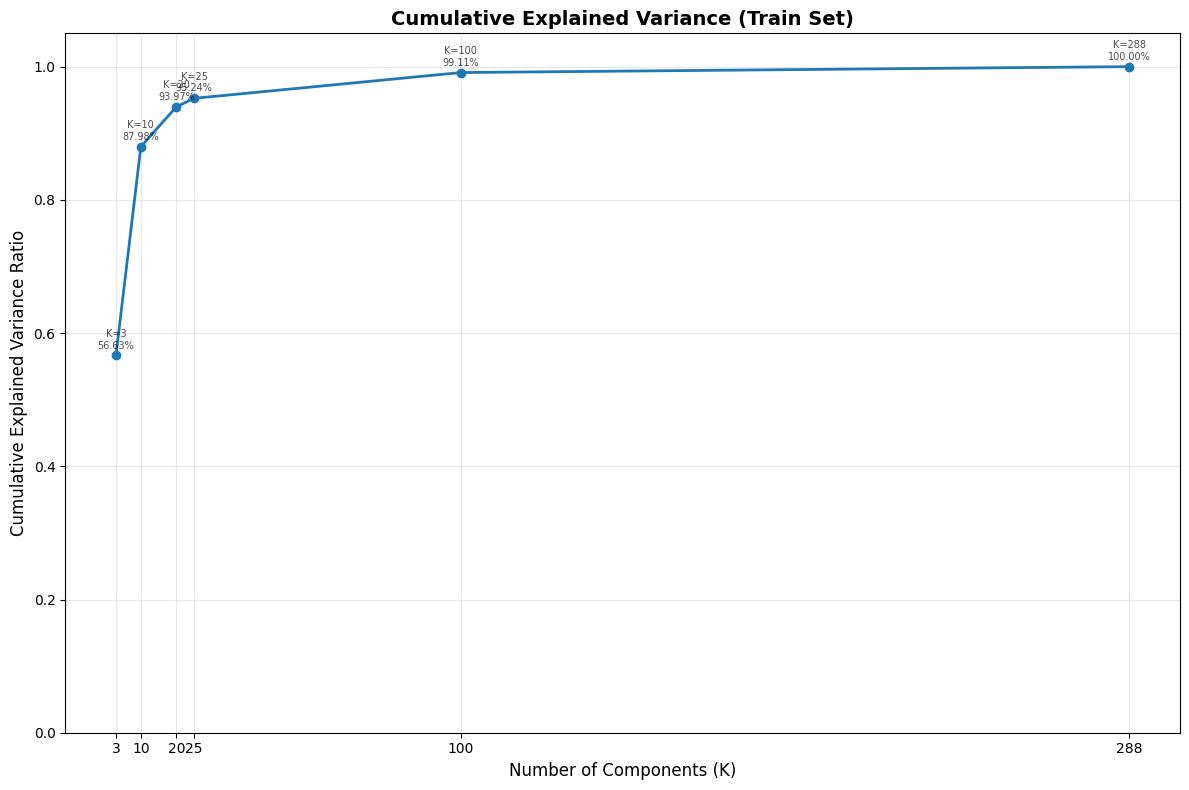

Saved plot: C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\models\data_00_20_w724_s10\PCA_cholesky\plots\reconstruction_errors_train_matrix.png


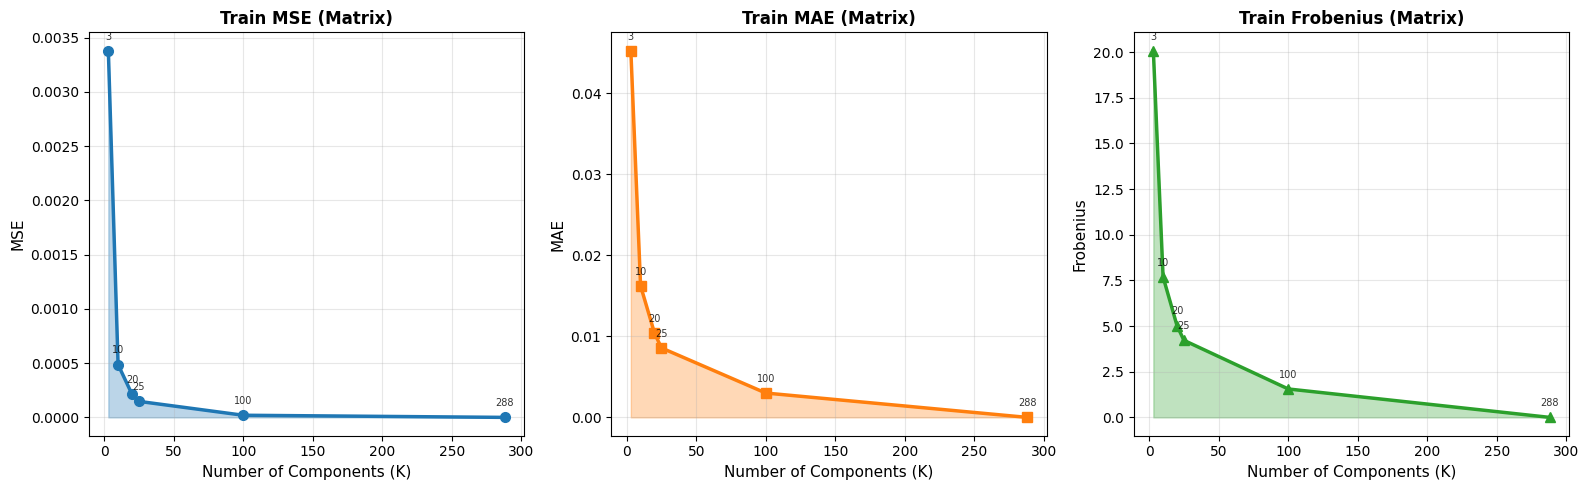

Saved plot: C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\models\data_00_20_w724_s10\PCA_cholesky\plots\reconstruction_errors_val_matrix.png


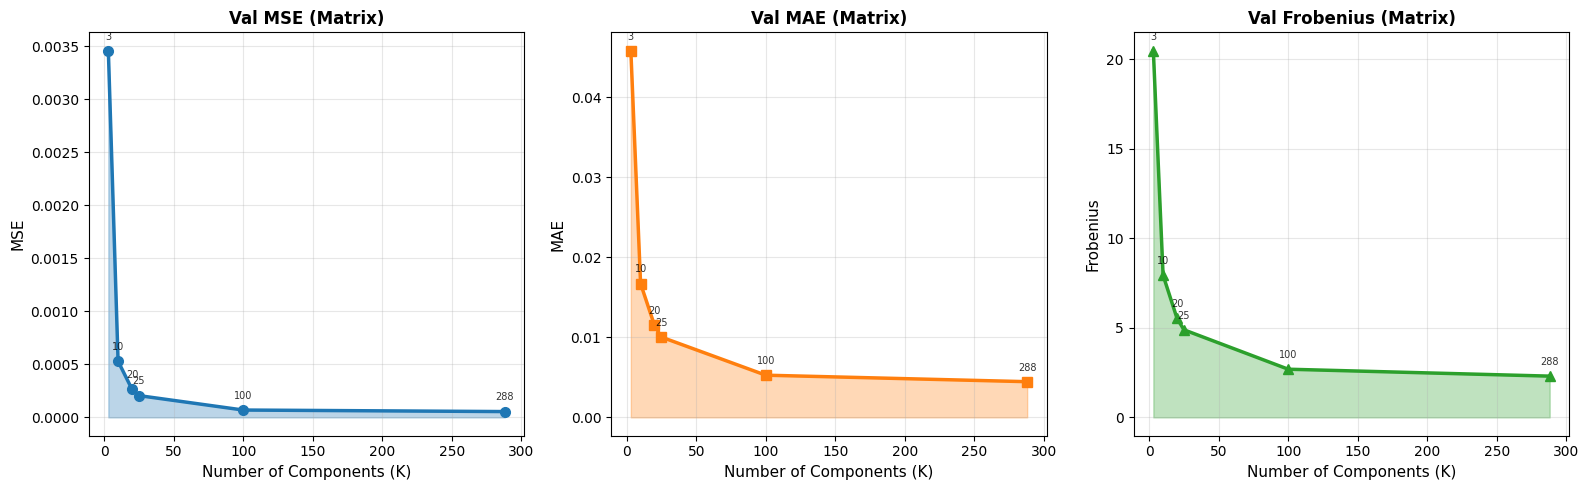

Saved plot: C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\models\data_00_20_w724_s10\PCA_cholesky\plots\reconstruction_errors_test_matrix.png


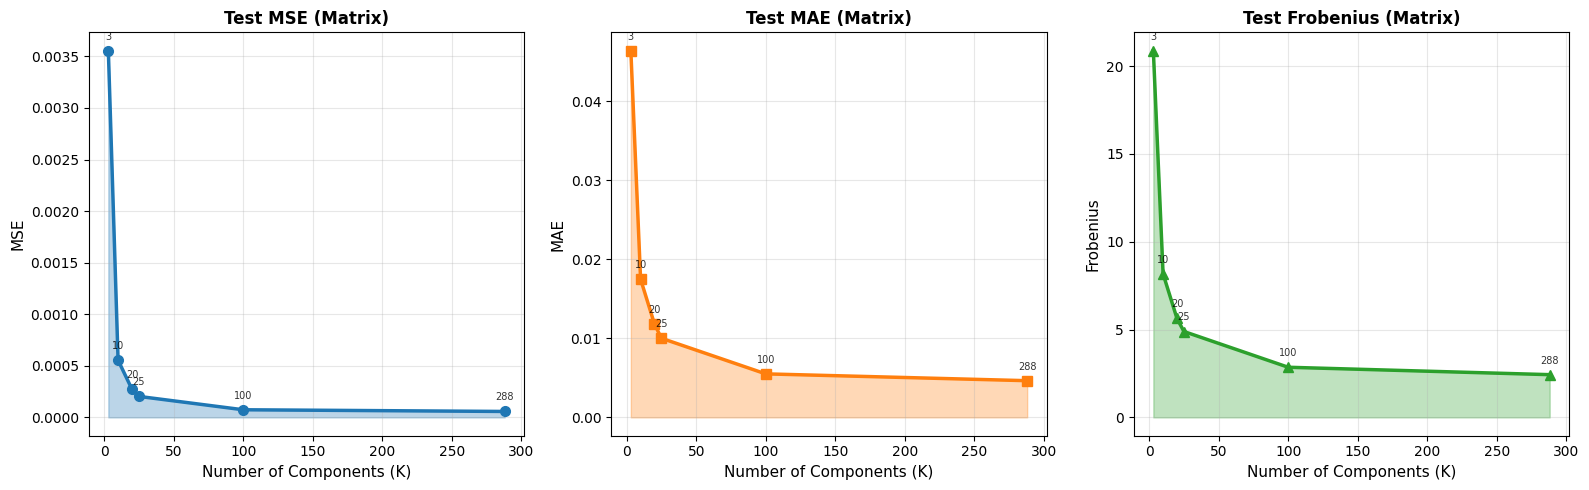

In [30]:

# Plot 1: Cumulative Explained Variance (train fit)
plot_dir = Path(f'../models/{FILE_NAME}_w{WINDOW_SIZE}_s{STRIDE}/PCA_cholesky/plots')
plot_dir.mkdir(parents=True, exist_ok=True)

fig1, ax1 = plt.subplots(figsize=(12, 8))

k_values = sweep_df['n_components'].to_numpy()
mean_cum_var = sweep_df['mean_explained_variance'].to_numpy()
ax1.plot(k_values, mean_cum_var, marker='o', linewidth=2, markersize=6)

# Add annotations with cumulative variance values at each marker
for k, val in zip(k_values, mean_cum_var):
    ax1.annotate(f'K={int(k)}\n{val*100:.2f}%',
                 xy=(k, val),
                 xytext=(0, 5),
                 textcoords='offset points',
                 ha='center',
                 fontsize=7,
                 alpha=0.7)

ax1.set_title(f'Cumulative Explained Variance (Train Set)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Number of Components (K)', fontsize=12)
ax1.set_ylabel('Cumulative Explained Variance Ratio', fontsize=12)
ax1.set_xticks(k_values)
ax1.set_ylim(0, 1.05)
ax1.grid(True, alpha=0.3)
plt.tight_layout()

fig1_path = plot_dir / 'cumulative_explained_variance.png'
fig1.savefig(fig1_path, dpi=300, bbox_inches='tight')
print(f'Saved plot: {fig1_path.resolve()}')

plt.show()

# ==========================================
# Plot 2: Train matrix errors (MSE/MAE/Frobenius)
# ==========================================
fig2, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].plot(sweep_df['n_components'], sweep_df['Train_matrix_MSE_mean'], marker='o', linewidth=2.5, markersize=7, color='#1f77b4')
axes[0].fill_between(sweep_df['n_components'], sweep_df['Train_matrix_MSE_mean'], alpha=0.3, color='#1f77b4')
for n_comp, val in zip(sweep_df['n_components'], sweep_df['Train_matrix_MSE_mean']):
    axes[0].annotate(f'{int(n_comp)}', xy=(n_comp, val), xytext=(0, 8), textcoords='offset points', ha='center', fontsize=7, alpha=0.8)
axes[0].set_title(f'Train MSE (Matrix)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Components (K)', fontsize=11)
axes[0].set_ylabel('MSE', fontsize=11)
axes[0].grid(True, alpha=0.3)

axes[1].plot(sweep_df['n_components'], sweep_df['Train_matrix_MAE_mean'], marker='s', linewidth=2.5, markersize=7, color='#ff7f0e')
axes[1].fill_between(sweep_df['n_components'], sweep_df['Train_matrix_MAE_mean'], alpha=0.3, color='#ff7f0e')
for n_comp, val in zip(sweep_df['n_components'], sweep_df['Train_matrix_MAE_mean']):
    axes[1].annotate(f'{int(n_comp)}', xy=(n_comp, val), xytext=(0, 8), textcoords='offset points', ha='center', fontsize=7, alpha=0.8)
axes[1].set_title(f'Train MAE (Matrix)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Components (K)', fontsize=11)
axes[1].set_ylabel('MAE', fontsize=11)
axes[1].grid(True, alpha=0.3)

axes[2].plot(sweep_df['n_components'], sweep_df['Train_matrix_Frobenius_mean'], marker='^', linewidth=2.5, markersize=7, color='#2ca02c')
axes[2].fill_between(sweep_df['n_components'], sweep_df['Train_matrix_Frobenius_mean'], alpha=0.3, color='#2ca02c')
for n_comp, val in zip(sweep_df['n_components'], sweep_df['Train_matrix_Frobenius_mean']):
    axes[2].annotate(f'{int(n_comp)}', xy=(n_comp, val), xytext=(0, 8), textcoords='offset points', ha='center', fontsize=7, alpha=0.8)
axes[2].set_title(f'Train Frobenius (Matrix)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Number of Components (K)', fontsize=11)
axes[2].set_ylabel('Frobenius', fontsize=11)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()

fig2_path = plot_dir / 'reconstruction_errors_train_matrix.png'
fig2.savefig(fig2_path, dpi=300, bbox_inches='tight')
print(f'Saved plot: {fig2_path.resolve()}')

plt.show()

# ==========================================
# Plot 3: Val matrix errors (MSE/MAE/Frobenius)
# ==========================================
fig3, axes_val = plt.subplots(1, 3, figsize=(16, 5))

axes_val[0].plot(sweep_df['n_components'], sweep_df['Val_matrix_MSE_mean'], marker='o', linewidth=2.5, markersize=7, color='#1f77b4')
axes_val[0].fill_between(sweep_df['n_components'], sweep_df['Val_matrix_MSE_mean'], alpha=0.3, color='#1f77b4')
for n_comp, val in zip(sweep_df['n_components'], sweep_df['Val_matrix_MSE_mean']):
    axes_val[0].annotate(f'{int(n_comp)}', xy=(n_comp, val), xytext=(0, 8), textcoords='offset points', ha='center', fontsize=7, alpha=0.8)
axes_val[0].set_title(f'Val MSE (Matrix)', fontsize=12, fontweight='bold')
axes_val[0].set_xlabel('Number of Components (K)', fontsize=11)
axes_val[0].set_ylabel('MSE', fontsize=11)
axes_val[0].grid(True, alpha=0.3)

axes_val[1].plot(sweep_df['n_components'], sweep_df['Val_matrix_MAE_mean'], marker='s', linewidth=2.5, markersize=7, color='#ff7f0e')
axes_val[1].fill_between(sweep_df['n_components'], sweep_df['Val_matrix_MAE_mean'], alpha=0.3, color='#ff7f0e')
for n_comp, val in zip(sweep_df['n_components'], sweep_df['Val_matrix_MAE_mean']):
    axes_val[1].annotate(f'{int(n_comp)}', xy=(n_comp, val), xytext=(0, 8), textcoords='offset points', ha='center', fontsize=7, alpha=0.8)
axes_val[1].set_title(f'Val MAE (Matrix)', fontsize=12, fontweight='bold')
axes_val[1].set_xlabel('Number of Components (K)', fontsize=11)
axes_val[1].set_ylabel('MAE', fontsize=11)
axes_val[1].grid(True, alpha=0.3)

axes_val[2].plot(sweep_df['n_components'], sweep_df['Val_matrix_Frobenius_mean'], marker='^', linewidth=2.5, markersize=7, color='#2ca02c')
axes_val[2].fill_between(sweep_df['n_components'], sweep_df['Val_matrix_Frobenius_mean'], alpha=0.3, color='#2ca02c')
for n_comp, val in zip(sweep_df['n_components'], sweep_df['Val_matrix_Frobenius_mean']):
    axes_val[2].annotate(f'{int(n_comp)}', xy=(n_comp, val), xytext=(0, 8), textcoords='offset points', ha='center', fontsize=7, alpha=0.8)
axes_val[2].set_title(f'Val Frobenius (Matrix)', fontsize=12, fontweight='bold')
axes_val[2].set_xlabel('Number of Components (K)', fontsize=11)
axes_val[2].set_ylabel('Frobenius', fontsize=11)
axes_val[2].grid(True, alpha=0.3)

plt.tight_layout()

fig3_path = plot_dir / 'reconstruction_errors_val_matrix.png'
fig3.savefig(fig3_path, dpi=300, bbox_inches='tight')
print(f'Saved plot: {fig3_path.resolve()}')

plt.show()

# ==========================================
# Plot 4: Test matrix errors (MSE/MAE/Frobenius)
# ==========================================
fig4, axes_test = plt.subplots(1, 3, figsize=(16, 5))

axes_test[0].plot(sweep_df['n_components'], sweep_df['Test_matrix_MSE_mean'], marker='o', linewidth=2.5, markersize=7, color='#1f77b4')
axes_test[0].fill_between(sweep_df['n_components'], sweep_df['Test_matrix_MSE_mean'], alpha=0.3, color='#1f77b4')
for n_comp, val in zip(sweep_df['n_components'], sweep_df['Test_matrix_MSE_mean']):
    axes_test[0].annotate(f'{int(n_comp)}', xy=(n_comp, val), xytext=(0, 8), textcoords='offset points', ha='center', fontsize=7, alpha=0.8)
axes_test[0].set_title(f'Test MSE (Matrix)', fontsize=12, fontweight='bold')
axes_test[0].set_xlabel('Number of Components (K)', fontsize=11)
axes_test[0].set_ylabel('MSE', fontsize=11)
axes_test[0].grid(True, alpha=0.3)

axes_test[1].plot(sweep_df['n_components'], sweep_df['Test_matrix_MAE_mean'], marker='s', linewidth=2.5, markersize=7, color='#ff7f0e')
axes_test[1].fill_between(sweep_df['n_components'], sweep_df['Test_matrix_MAE_mean'], alpha=0.3, color='#ff7f0e')
for n_comp, val in zip(sweep_df['n_components'], sweep_df['Test_matrix_MAE_mean']):
    axes_test[1].annotate(f'{int(n_comp)}', xy=(n_comp, val), xytext=(0, 8), textcoords='offset points', ha='center', fontsize=7, alpha=0.8)
axes_test[1].set_title(f'Test MAE (Matrix)', fontsize=12, fontweight='bold')
axes_test[1].set_xlabel('Number of Components (K)', fontsize=11)
axes_test[1].set_ylabel('MAE', fontsize=11)
axes_test[1].grid(True, alpha=0.3)

axes_test[2].plot(sweep_df['n_components'], sweep_df['Test_matrix_Frobenius_mean'], marker='^', linewidth=2.5, markersize=7, color='#2ca02c')
axes_test[2].fill_between(sweep_df['n_components'], sweep_df['Test_matrix_Frobenius_mean'], alpha=0.3, color='#2ca02c')
for n_comp, val in zip(sweep_df['n_components'], sweep_df['Test_matrix_Frobenius_mean']):
    axes_test[2].annotate(f'{int(n_comp)}', xy=(n_comp, val), xytext=(0, 8), textcoords='offset points', ha='center', fontsize=7, alpha=0.8)
axes_test[2].set_title(f'Test Frobenius (Matrix)', fontsize=12, fontweight='bold')
axes_test[2].set_xlabel('Number of Components (K)', fontsize=11)
axes_test[2].set_ylabel('Frobenius', fontsize=11)
axes_test[2].grid(True, alpha=0.3)

plt.tight_layout()

fig4_path = plot_dir / 'reconstruction_errors_test_matrix.png'
fig4.savefig(fig4_path, dpi=300, bbox_inches='tight')
print(f'Saved plot: {fig4_path.resolve()}')
plt.show()